# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [7]:
# Import the library
from PIL import Image, ImageOps
import numpy as np


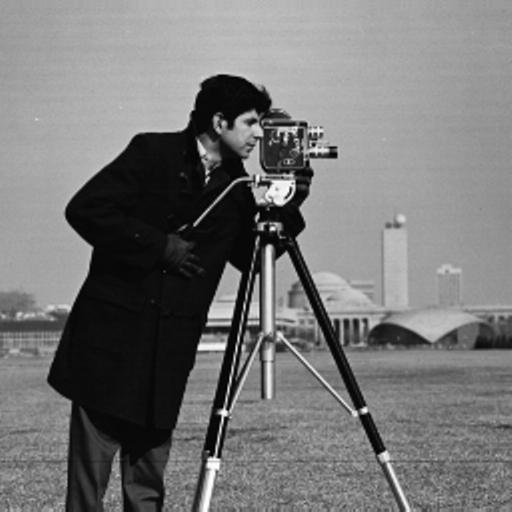

In [9]:
# ── Load image ────────────────────────────────────
IMAGE_PATH = r"C:\Users\Nabaa\OneDrive\Desktop\level7\IP-Lab\lab3-image.png"  # <-- update this path/filename to your image
img = Image.open(IMAGE_PATH).convert("RGB")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [ ]:
# Get the size of the image
img_width, img_height = img.size
print(f"Original size: {img_width}x{img_height}")
# scaling factors
scale_x, scale_y = 2, 2
new_width, new_height = img_width * scale_x, img_height * scale_y
print(f"New size: {new_width}x{new_height}")


Original size: 512x512
New size: 1024x1024


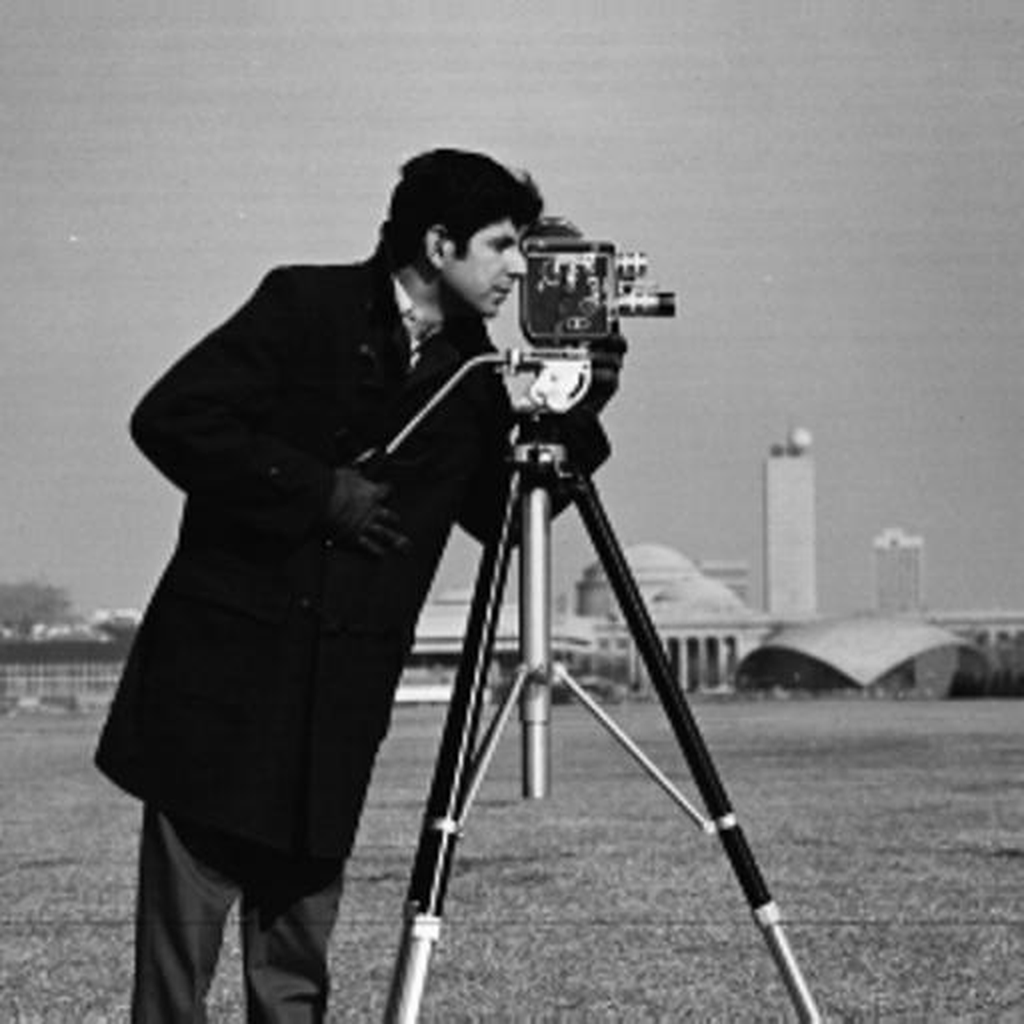

In [21]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
resized_img = img.resize((new_width, new_height), Image.LANCZOS)
resized_img


In [23]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
resized_img.save("task1_1_scaled.jpg")
print(f"Saved scaled image as 'task1_1_scaled.jpg'")

Saved scaled image as 'task1_1_scaled.jpg'


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [29]:
cx, cy = 2, 1
nu_width, nu_height = int(img_width * cx), int(img_height * cy)

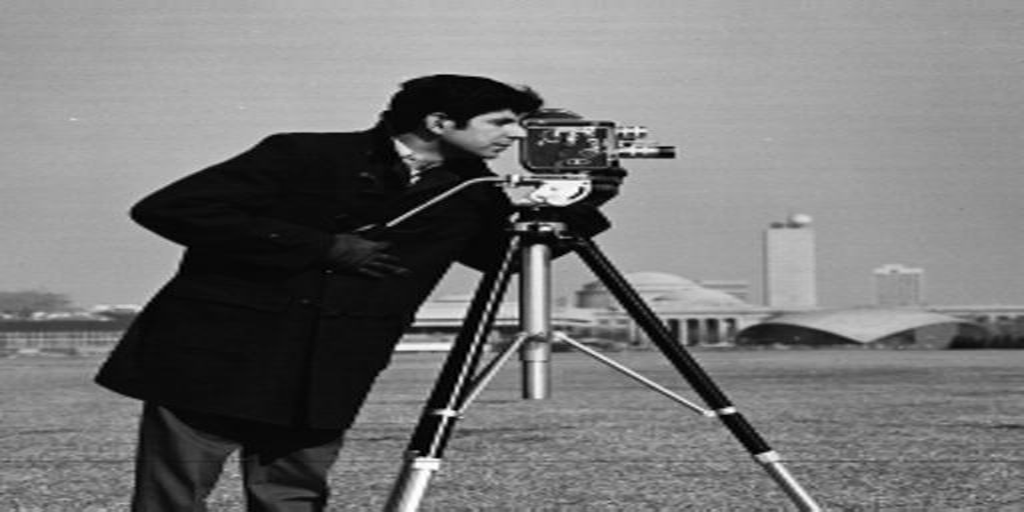

In [31]:
nonuniform_img = img.resize((nu_width, nu_height), Image.LANCZOS)
nonuniform_img

In [33]:
nonuniform_img.save("task1_1b_nonuniform_scaled.jpg")
print(f"Saved non-uniformly scaled image as 'task1_1b_nonuniform_scaled.jpg'")

Saved non-uniformly scaled image as 'task1_1b_nonuniform_scaled.jpg'


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

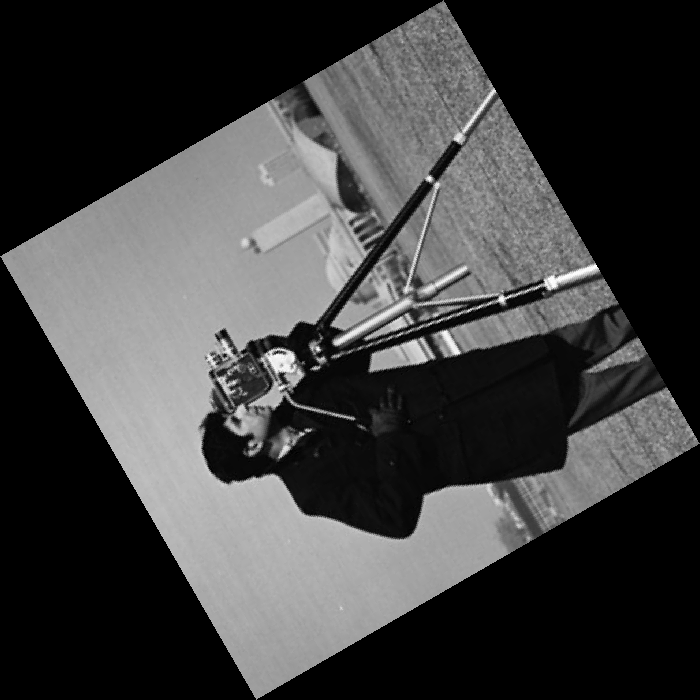

In [34]:
#── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img

In [35]:
rotated_img.save("task1_2_rotated.jpg")
print(f"Saved rotated image as 'task1_2_rotated.jpg'")

Saved rotated image as 'task1_2_rotated.jpg'


### 3. Shear

In [ ]:
# -- c. Get the image dimensions ────────────────────
img_width, img_height = img.size


In [56]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.8
new_width = img_width + int(shear_factor * img_height)
shear_matrix = (1, shear_factor, 0, 0, 1, 0)

In [57]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, img_height),
    Image.AFFINE,
    shear_matrix,
    resample=Image.BICUBIC
)


In [58]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3.4_sheared.jpg")
print(f"Saved sheared image as 'task1_3_sheared.jpg'")

Saved sheared image as 'task1_3_sheared.jpg'


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

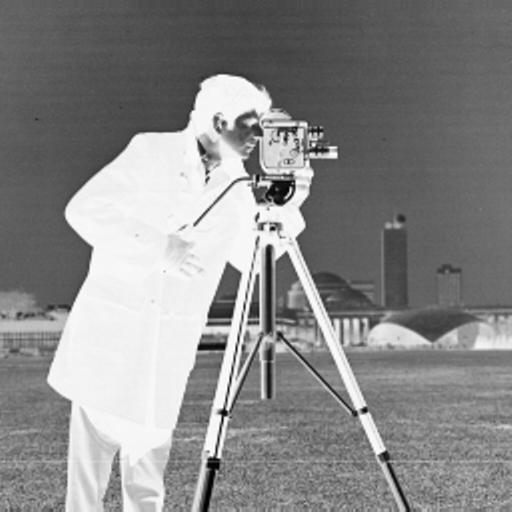

In [ ]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img_np = Image.fromarray(negative_arr.astype(np.uint8))
negative_img_np.save("task2_1_negative_numpy.jpg")
negative_img_np



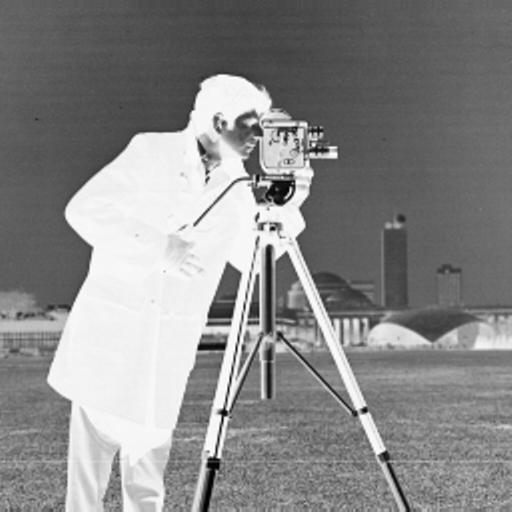

In [60]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img.convert("RGB"))
negative_img_pil.save("task2_1_negative_pil.jpg")
negative_img_pil

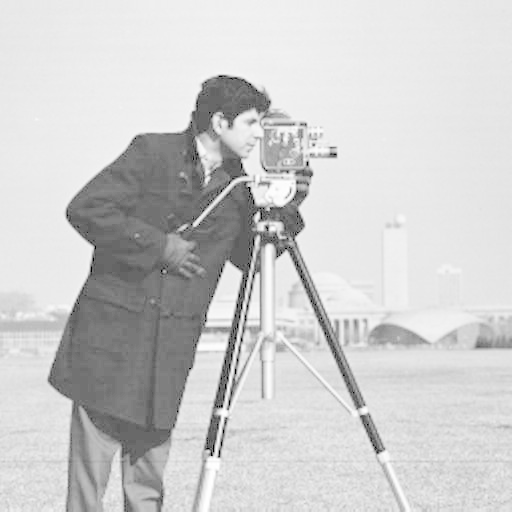

In [61]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
arr = np.array(img).astype(np.float64)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_transformed_arr)
log_img.save("task2_2_log.jpg")
log_img



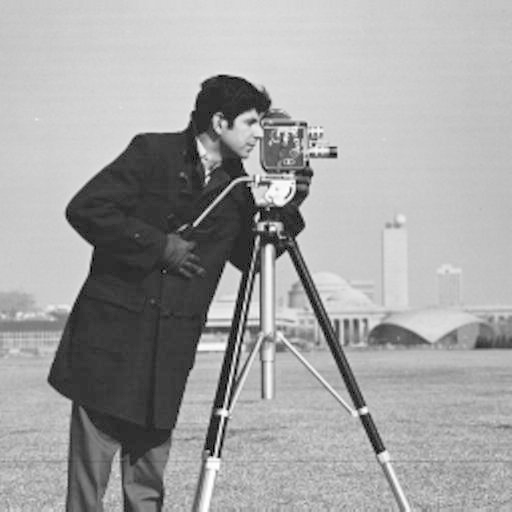

In [62]:

# ── 3. Power-law / Gamma correction ───────────────
arr = np.array(img).astype(np.float64)

gamma = 0.5  # <1 brightens, >1 darkens -- try 0.4, 1.5, 2.2 to compare
c = 255.0  # normalization constant so max input (255) maps to max output (255)

gamma_corrected = c * (arr / 255.0) ** gamma
gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_corrected)
gamma_img.save("task2_3_gamma.jpg")
gamma_img